In [12]:
#%% CALCULATING SECTOR SPECIFIC Fe EMISSIONS FROM CMIP BLACK CARBON EMISSION DATASETS  ----------------------
import xarray as xr
import pandas as pd
import numpy as np

# Load the NetCDF file -- BC EMISSIONS PD
ds_BC = xr.open_dataset("BC-em-anthro_input4MIPs_emissions_CMIP_CEDS-2017-05-18_gn_2000-2015MEAN_remapcon_regridded.nc")
ds_BC = ds_BC.drop_vars(["time_bnds", "sector_bnds", "time"])
ds_BC = ds_BC.squeeze(dim='time') 

# Load the NetCDF file -- Fe EMISSIONS PD CMIP6 (use as OCNFRAC too)
ds_PD_Fe = xr.open_dataset("ClaquinMineralsCAM6_SPEWFUELS-Dec2023_OCNFRAC_remapcon_regridded.nc")
ds_PD_Fe['OCNFRAC'] = ds_PD_Fe['OCNFRAC'].squeeze(dim='time')
ds_PD_Fe = ds_PD_Fe.drop_dims(["time"]) 

# Extract Black Carbon (BC) & calculate emission budgets for each sector
BC_em_anthro = ds_BC['BC_em_anthro'] # Emission data
lon = ds_BC['lon'].values  # Longitude values -- the .values extracts as a numPy array, removes metadata
lat = ds_BC['lat'].values  # Latitude values
sector = ds_BC['sector'].values # Sector identifiers

# CMIP SECTORS 
#0: Agriculture; 
#1: Energy;  
#2: Industrial; 
#3: Transportation; 
#4: Residential, Commercial, Other; 
#5: Solvents production and application; 
#6: Waste; 
#7: International Shipping

# for oil -- must split shipping and terrestrial by ocean cells
ocnfrac = ds_PD_Fe['OCNFRAC'] 
ocnfrac_expanded = ocnfrac.expand_dims(dim={'sector': BC_em_anthro['sector']}, axis=0)
BC_em_anthro['OCNFRAC'] = ocnfrac_expanded
BC_emiss_3 = BC_em_anthro.isel(sector=3).copy()  # Transportation
filtered_BC_emiss_3 = BC_emiss_3.where(ocnfrac < 0.5)
filtered_BC_emiss_3 = filtered_BC_emiss_3.drop_vars(['time','OCNFRAC','sector'], errors= 'ignore')
BC_emiss_7 = BC_em_anthro.isel(sector=7).copy()  # Shipping
filtered_BC_emiss_7 = BC_emiss_7.where(ocnfrac >= 0.5)
filtered_BC_emiss_7 = filtered_BC_emiss_7.drop_vars(['time','OCNFRAC','sector'], errors= 'ignore')

# for residential coal vs residential wood/biofuel, split sector 4 based on ratios from Bond 2004
# (35% residential coal, 65% residential wood + biof + ag)

BC_emiss_Ag = BC_em_anthro.isel(sector=0).copy()
BC_emiss_Ag = BC_emiss_Ag.drop_vars(['sector'])
BC_emiss_1 = BC_em_anthro.isel(sector=1).copy() 
BC_emiss_1 = BC_emiss_1.drop_vars(['sector'])
BC_emiss_2 = BC_em_anthro.isel(sector=2).copy() 
BC_emiss_2 = BC_emiss_2.drop_vars(['sector'])
BC_emiss_Ind = BC_emiss_1 + BC_emiss_2
BC_emiss_Oil = filtered_BC_emiss_3.fillna(filtered_BC_emiss_7) 
BC_emiss_4 = BC_em_anthro.isel(sector=4).copy()  
BC_emiss_4 = BC_emiss_4.drop_vars(['sector'])
BC_emiss_4 = BC_emiss_4 # + BC_emiss_Ag # remove this because so small but adds a lot of BC from Bond
BC_emiss_Resi = BC_emiss_4*(480/(480+208+880)) # from the Bond 2004 Table 15
BC_emiss_Biof = BC_emiss_4*((208+880)/(480+208+880)) # from the Bond 2004 Table 15
BC_emiss_Was = BC_em_anthro.isel(sector=6).copy() 
BC_emiss_Was = BC_emiss_Was.drop_vars(['sector'])

BC_emiss_ALL = xr.Dataset({
    'BC_Ag':  BC_emiss_Ag,
    'BC_IndCoal': BC_emiss_Ind,
    'BC_Oil': BC_emiss_Oil,
    'BC_4' : BC_emiss_4,
    'BC_ResiCoal':  BC_emiss_Resi,
    'BC_Biof':  BC_emiss_Biof,
    'BC_Waste': BC_emiss_Was
})
BC_emiss_ALL = BC_emiss_ALL.reset_coords('OCNFRAC', drop=True)
#print(BC_emiss_ALL)

In [13]:
# Calculate BC emissions budget for each sector grouping
from typing import Union
EARTH_RADIUS_M   = 6.3781E6         # mean Earth radius, metres
KG_TO_TG         = 1e-9             # 1 Gg = 1e6 kg, 1 Tg = 1e9 kg
SECONDS_PER_YEAR = 365 * 24 * 3600  # s year-1

def _centres_to_edges_1d(centres: np.ndarray) -> np.ndarray:
    c = np.asarray(centres, dtype=float)
    edges = np.empty(len(c) + 1)
    edges[1:-1] = 0.5 * (c[:-1] + c[1:])
    edges[0]    = c[0]  - 0.5 * (c[1]  - c[0])
    edges[-1]   = c[-1] + 0.5 * (c[-1] - c[-2])
    return edges

def compute_cell_areas(lat_centres: np.ndarray, lon_centres: np.ndarray) -> np.ndarray:   
    lat_edges = _centres_to_edges_1d(lat_centres)
    lon_edges = _centres_to_edges_1d(lon_centres)
    lat_rad_s = np.deg2rad(lat_edges[:-1])
    lat_rad_n = np.deg2rad(lat_edges[1:])
    lon_rad_w = np.deg2rad(lon_edges[:-1])
    lon_rad_e = np.deg2rad(lon_edges[1:])
    delta_lon = np.abs(lon_rad_e - lon_rad_w)                        
    delta_sin = np.abs(np.sin(lat_rad_n) - np.sin(lat_rad_s))       
    return EARTH_RADIUS_M**2 * np.outer(delta_sin, delta_lon)         

def compute_emission_budget(
    flux: Union[np.ndarray, xr.DataArray],
    lat:  np.ndarray,
    lon:  np.ndarray,) -> dict:
    flux_np = flux.values if isinstance(flux, xr.DataArray) else np.asarray(flux, dtype=float)
    lat_np  = np.asarray(lat, dtype=float)
    lon_np  = np.asarray(lon, dtype=float)
    area = compute_cell_areas(lat_np, lon_np)
    # kg m-2 s-1  ×  s yr-1  ×  m²  =  kg yr-1  per cell
    column_flux_kg = flux_np * SECONDS_PER_YEAR * area
    total_Tg_per_year = np.nansum(column_flux_kg) * KG_TO_TG
    return {
        "budget_Tg_per_year":    total_Tg_per_year,
        "cell_areas_m2":         area,
        "column_flux_kg_per_yr": column_flux_kg,
    }

def budget_all_variables(
    ds:       xr.Dataset,
    lat_name: str = "lat",
    lon_name: str = "lon",) -> pd.DataFrame:
    lat = ds[lat_name].values
    lon = ds[lon_name].values
    records = []
    for var in ds:
        da = ds[var]
        da = da.squeeze()
        if lat_name in da.dims and lon_name in da.dims:
            da = da.transpose(lat_name, lon_name)
        result = compute_emission_budget(flux=da, lat=lat, lon=lon)
        records.append({
            "variable":           var,
            "budget_Tg_per_year": result["budget_Tg_per_year"],})
    df = pd.DataFrame(records).sort_values("budget_Tg_per_year", ascending=False)
    df = df.reset_index(drop=True)
    return df

def compute_emission_budget_xr(
    flux: xr.DataArray,
    lat: np.ndarray,
    lon: np.ndarray,
) -> xr.DataArray:
    result = compute_emission_budget(flux, lat, lon)

    # convert kg → Tg per cell
    cell_Tg = result["column_flux_kg_per_yr"] * KG_TO_TG

    return xr.DataArray(
        cell_Tg,
        coords={ "lat": lat, "lon": lon },
        dims=("lat", "lon"),
        name=flux.name,
        attrs={"units": "Tg/yr per grid cell"}
    )

def budget_per_cell_dataset(
    ds: xr.Dataset,
    lat_name: str = "lat",
    lon_name: str = "lon",
) -> xr.Dataset:
    lat = ds[lat_name].values
    lon = ds[lon_name].values

    out = {}

    for var in ds:
        da = ds[var].squeeze()

        if lat_name in da.dims and lon_name in da.dims:
            da = da.transpose(lat_name, lon_name)

        out[var] = compute_emission_budget_xr(da, lat, lon)

    return xr.Dataset(out)

# now run the actual function
BC_BUDGETS = budget_all_variables(BC_emiss_ALL, lat_name="lat", lon_name="lon")
#print(BC_BUDGETS) 

# RESULTS <- because Ag is so small -- remove this from SAGAR'S Table and just ignore

In [15]:
# OUR DATASET SEPARATION
# FOIL = 3 (only from terrestrial cells) + 7 (only from ocean cells)
# FWOOD = partial (4 + 0)
# FSMELT = NA -- will remain the same
# FCOALFF = 1 + 2
# FCOALBF = partial (4 + 0)
# FWASTE = 6
import xarray as xr
import pandas as pd
import numpy as np

ds_Fe_OG = xr.open_dataset("Fe_Emissions_FUEL_regridded.nc")
ds_Fe_OG = xr.open_dataset("ClaquinMineralsCAM6_SPEWFUELS-Dec2023.nc") 
#print(ds_Fe_OG) # <- they are separated by Coa and coarse, so the ratios do need to be size specific

# add industrial coal and residential coal back together 
ds_Fe_OG['FineMed_FCOAL'] = ds_Fe_OG['FineMed_FCOALFF'] + ds_Fe_OG['FineMed_FCOALBF']
ds_Fe_OG['CoaMed_FCOAL'] = ds_Fe_OG['CoaMed_FCOALFF'] + ds_Fe_OG['CoaMed_FCOALBF']

# STEP 1: remove some of the unexplained mass from Sagar's original file. We do not know where this
# NOT NEEDED WHEN KEEPING THE BOTTOM LINE EQUAL TO THE CLAQUIN ORIGINAL FILE
# came from, but I am reducing the mass in the fine and coarse fraction accordingly so that their 
# global budget sums match those reported in Rathod et al 2020 Table S6 for coal sources
# ds_Fe_OG['FineMed_FCOAL'] = ds_Fe_OG['FineMed_FCOAL'] * 0.9125 
# ds_Fe_OG['CoaMed_FCOAL'] = ds_Fe_OG['CoaMed_FCOAL'] * 0.9711

# STEP 2: Separate FCOAL into FCOALBF (RESI) and FCOALFF (IND) using ratios of residential to industrial 
# sources reported in Rathod et al., 2020. These are mode specific. I will make a flow chart and copy the tables over
# into the SI material illustrating all of this 
ds_Fe_OG['FineMed_FCOALBF'] = ds_Fe_OG['FineMed_FCOAL'] * 0.0116
ds_Fe_OG['FineMed_FCOALFF'] = ds_Fe_OG['FineMed_FCOAL'] * 0.9884
ds_Fe_OG['CoaMed_FCOALBF'] = ds_Fe_OG['CoaMed_FCOAL'] * 0.0042
ds_Fe_OG['CoaMed_FCOALFF'] = ds_Fe_OG['CoaMed_FCOAL'] * 0.9958 

# STEP 3: Separate FWOOD into WOOD/BIOF and WASTE to follow Rathod and CMIP. also size dependent
ds_Fe_OG['FineMed_FWASTE'] = ds_Fe_OG['FineMed_FWOOD'] * 0.0002
ds_Fe_OG['FineMed_FWOOD'] = ds_Fe_OG['FineMed_FWOOD'] * 0.9998
ds_Fe_OG['FineMed_FWW'] = ds_Fe_OG['FineMed_FWASTE'] + ds_Fe_OG['FineMed_FWOOD']
ds_Fe_OG['CoaMed_FWASTE'] = ds_Fe_OG['CoaMed_FWOOD'] * 0.0643 # updated after removing Ag
ds_Fe_OG['CoaMed_FWOOD'] = ds_Fe_OG['CoaMed_FWOOD'] * 0.9357 # updated after removing Ag
ds_Fe_OG['CoaMed_FWW'] = ds_Fe_OG['CoaMed_FWASTE'] + ds_Fe_OG['CoaMed_FWOOD']

# Quick math for calculating new budgets
ds_Fe_OG['FWASTE'] = ds_Fe_OG['FineMed_FWASTE'] + ds_Fe_OG['CoaMed_FWASTE']
ds_Fe_OG['FWOOD'] = ds_Fe_OG['FineMed_FWOOD'] + ds_Fe_OG['CoaMed_FWOOD']
ds_Fe_OG['FWW'] = ds_Fe_OG['FineMed_FWW'] + ds_Fe_OG['CoaMed_FWW']
ds_Fe_OG['FRESI'] = ds_Fe_OG['FineMed_FCOALBF'] + ds_Fe_OG['CoaMed_FCOALBF']
ds_Fe_OG['FIND'] = ds_Fe_OG['FineMed_FCOALFF'] + ds_Fe_OG['CoaMed_FCOALFF']
ds_Fe_OG['FSMELT'] = ds_Fe_OG['FineMed_FSMELT'] + ds_Fe_OG['CoaMed_FSMELT']
ds_Fe_OG['FOIL'] = ds_Fe_OG['FineMed_FOIL'] + ds_Fe_OG['CoaMed_FOIL']
ds_Fe_OG['FCOAL'] = ds_Fe_OG['FineMed_FCOAL'] + ds_Fe_OG['CoaMed_FCOAL']

ds_Fe_OG['FTOTAL'] = ds_Fe_OG['FWASTE'] + ds_Fe_OG['FWOOD'] + ds_Fe_OG['FRESI'] + ds_Fe_OG['FIND'] + ds_Fe_OG['FSMELT'] + ds_Fe_OG['FOIL']

Fe_emiss_ALL = xr.Dataset({
    'Waste':  ds_Fe_OG['FWASTE'],
    'Biof/Wood': ds_Fe_OG['FWOOD'],
    'Biof/Wood/Waste': ds_Fe_OG['FWW'],
    'All Coal':  ds_Fe_OG['FCOAL'],
    'Oil': ds_Fe_OG['FOIL'],
    'ResiCoal':  ds_Fe_OG['FRESI'],
    'IndCoal':  ds_Fe_OG['FIND'],
    'Smelt': ds_Fe_OG['FSMELT'],
    'TOTAL': ds_Fe_OG['FTOTAL'],
})

#print(ds_Fe_OG)

FE_BUDGETS = budget_all_variables(Fe_emiss_ALL, lat_name="lat", lon_name="lon")
print(FE_BUDGETS) 

          variable  budget_Tg_per_year
0            TOTAL            2.221016
1            Smelt            1.345343
2         All Coal            0.769665
3          IndCoal            0.764792
4  Biof/Wood/Waste            0.071520
5        Biof/Wood            0.070597
6              Oil            0.034487
7         ResiCoal            0.004873
8            Waste            0.000923


In [16]:
# Redistributing Fe emissions regionally based on BC:BC ratios 
# For Residential Coal, Residential Wood, Waste, and Industrial Coal
# First, plot emissions for all 

# Generating cell by cell ratios for each fuel type with exception of SMELT

BC_emiss = xr.Dataset({
    'BCCOALFF': BC_emiss_Ind,
#    'BCOIL': BC_emiss_Oil,
    'BCCOALBF':  BC_emiss_Resi,
    'BCWOOD':  BC_emiss_Biof,
    'BCWASTE': BC_emiss_Was
})

Fe_emiss = xr.Dataset({
    'FWASTE':  ds_Fe_OG['FWASTE'],
    'FWOOD': ds_Fe_OG['FWOOD'],
 #   'FOIL': ds_Fe_OG['FOIL'],
    'FCOALBF':  ds_Fe_OG['FRESI'],
    'FCOALFF':  ds_Fe_OG['FIND'],
#    'FSMELT': ds_Fe_OG['FSMELT'],
})

Fe_emiss = Fe_emiss.clip(min=0.0)
Fe_emiss = Fe_emiss.fillna(0) 

# first need to find the BUDGET for each cell
# per-cell budgets (Tg/yr per grid cell)
# ── per-cell budgets ──────────────────────────────────────────────────────────
BCij_BUDGETS = budget_per_cell_dataset(BC_emiss)
FEij_BUDGETS = budget_per_cell_dataset(Fe_emiss)

BC_GLOB_BUDG = BCij_BUDGETS.sum()
FE_GLOB_BUDG = FEij_BUDGETS.sum()

# ── BC spatial fractions (guard against zero-total fuel sources) ──────────────
BC_fracs = xr.Dataset()
for var in BCij_BUDGETS.data_vars:         
    total = BC_GLOB_BUDG[var].item()
    if total == 0:
        BC_fracs[var + "_frac"] = xr.zeros_like(BCij_BUDGETS[var])
    else:
        BC_fracs[var + "_frac"] = BCij_BUDGETS[var] / total
    BC_fracs[var + "_frac"].attrs["units"] = "fraction"

# ── global Fe budget broadcast onto the BC spatial grid ──────────────────────
# Crucially: use BC_fracs coords so the grids are guaranteed to align
Fe_global = xr.Dataset()
for var in Fe_emiss.data_vars:
    Fe_global[var] = xr.full_like(
        BC_fracs[next(iter(BC_fracs.data_vars))],  # match BC grid exactly
        fill_value=FE_GLOB_BUDG[var].item()
    )
    Fe_global[var].attrs["units"] = "Tg/yr"

# ── redistribute Fe using BC spatial pattern ─────────────────────────────────
Fe_redistributed = xr.Dataset()

fuel_map = {
    "FCOALFF": "BCCOALFF_frac",
    "FCOALBF": "BCCOALBF_frac",
    "FWOOD":   "BCWOOD_frac",
#    "FOIL":    "BCOIL_frac",
    "FWASTE":  "BCWASTE_frac",
}

for fe_var, bc_frac_var in fuel_map.items():
    Fe_redistributed[fe_var] = BC_fracs[bc_frac_var] * Fe_global[fe_var]
    Fe_redistributed[fe_var].attrs["units"] = "Tg/yr"

Fe_redistributed = Fe_redistributed.fillna(0.0)

#Fe_redistributed["FSMELT"] = Fe_emiss["FSMELT"]
FE_GLOB_BUDG2 = Fe_redistributed.sum()
print(FE_GLOB_BUDG2)

# ── compute cell areas on the BC/redistributed grid ──────────────────────────
lat_np = Fe_redistributed.lat.values
lon_np = Fe_redistributed.lon.values
area = compute_cell_areas(lat_np, lon_np)          # (nlat, nlon) m²

# wrap as DataArray so xarray handles broadcasting cleanly
area_da = xr.DataArray(area, dims=["lat", "lon"],
                        coords={"lat": Fe_redistributed.lat,
                                "lon": Fe_redistributed.lon})

# ── invert: Tg yr⁻¹ cell⁻¹  →  kg m⁻² s⁻¹ ───────────────────────────────────
Fe_redistributed_flux = xr.Dataset()
for var in Fe_redistributed.data_vars:
    Fe_redistributed_flux[var] = (
        Fe_redistributed[var]           # Tg yr⁻¹ per cell
        / KG_TO_TG                      # → kg yr⁻¹ per cell
        / SECONDS_PER_YEAR              # → kg s⁻¹ per cell
        / area_da                       # → kg m⁻² s⁻¹
    )
    Fe_redistributed_flux[var].attrs["units"] = "kg m-2 s-1"

Fe_redistributed_flux = Fe_redistributed_flux.fillna(0.0)

#print(Fe_redistributed)
FE_REDIB_BUDGETS = budget_all_variables(Fe_redistributed_flux, lat_name="lat", lon_name="lon")
print(FE_REDIB_BUDGETS)

<xarray.Dataset> Size: 32B
Dimensions:  ()
Data variables:
    FCOALFF  float64 8B 0.7653
    FCOALBF  float64 8B 0.004884
    FWOOD    float64 8B 0.0706
    FWASTE   float64 8B 0.0009227
  variable  budget_Tg_per_year
0  FCOALFF            0.765279
1    FWOOD            0.070597
2  FCOALBF            0.004884
3   FWASTE            0.000923


In [17]:
# need to split each into the coarse and fine fraction 

# for those that I can, find the gridded ratio of coarse to fine ? 
# or just use static ratios from Rathod 2024 -- easiest and most consistent with how we got to final mass

# THESE NUMBERS ARE FROM THE RATHOD 2020 PAPER
Fe_redistributed_flux["FineMed_FCOALBF"] = Fe_redistributed_flux["FCOALBF"] *  0.5083 
Fe_redistributed_flux["CoaMed_FCOALBF"] = Fe_redistributed_flux["FCOALBF"] * 0.4917
Fe_redistributed_flux["FineMed_FCOALFF"] = Fe_redistributed_flux["FCOALFF"] *  0.2726  
Fe_redistributed_flux["CoaMed_FCOALFF"] = Fe_redistributed_flux["FCOALFF"] * 0.7274
Fe_redistributed_flux["FineMed_FWOOD"] = Fe_redistributed_flux["FWOOD"] * 0.8100   
Fe_redistributed_flux["CoaMed_FWOOD"] = Fe_redistributed_flux["FWOOD"] * 0.1900
Fe_redistributed_flux["FineMed_FWASTE"] = Fe_redistributed_flux["FWASTE"] *  0.0134   
Fe_redistributed_flux["CoaMed_FWASTE"] = Fe_redistributed_flux["FWASTE"] * 0.9866

Fe_redistributed_flux = Fe_redistributed_flux.clip(min=0.0)
Fe_redistributed_flux = Fe_redistributed_flux.fillna(0.0)

FE_BUDGETS_final = budget_all_variables(Fe_redistributed_flux, lat_name="lat", lon_name="lon")
print(FE_BUDGETS_final) 
# passed test, mass conserved

           variable  budget_Tg_per_year
0           FCOALFF            0.765279
1    CoaMed_FCOALFF            0.556664
2   FineMed_FCOALFF            0.208615
3             FWOOD            0.070597
4     FineMed_FWOOD            0.057184
5      CoaMed_FWOOD            0.013413
6           FCOALBF            0.004884
7   FineMed_FCOALBF            0.002483
8    CoaMed_FCOALBF            0.002401
9            FWASTE            0.000923
10    CoaMed_FWASTE            0.000910
11   FineMed_FWASTE            0.000012


In [19]:
# print to netcdf

Fe_redistributed_flux.to_netcdf("ClaquinMineralsCAM6_SPEWFUELS-Mar2026_tmp.nc")

BEFORE REDISTRIBUTION


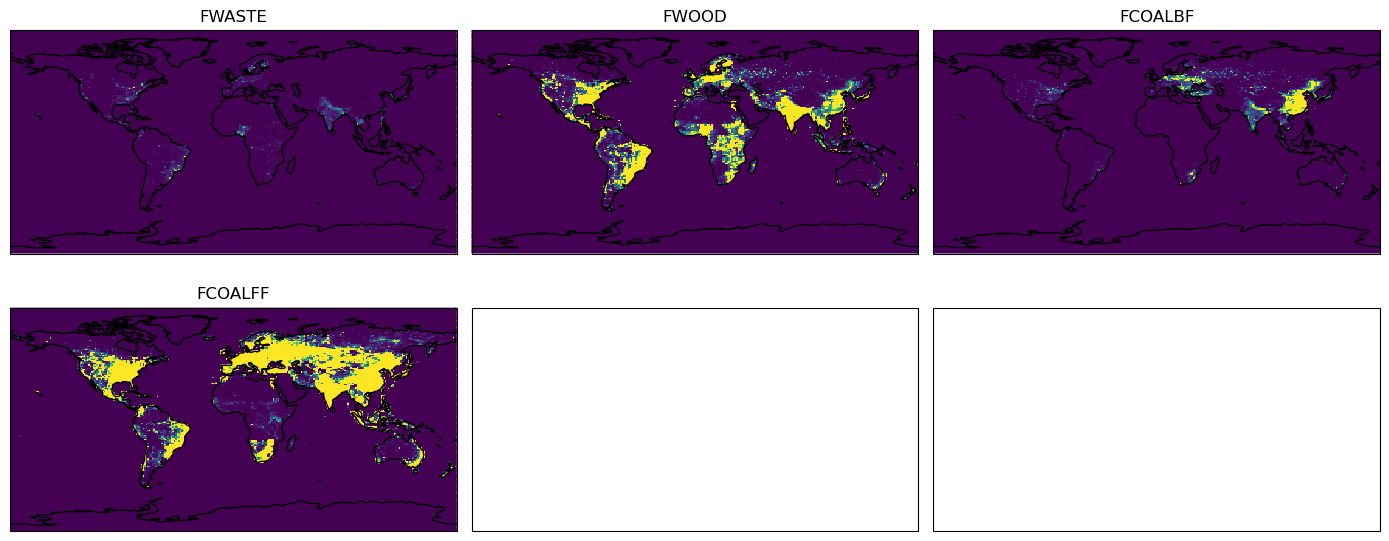

AFTER REDISTRIBUTION


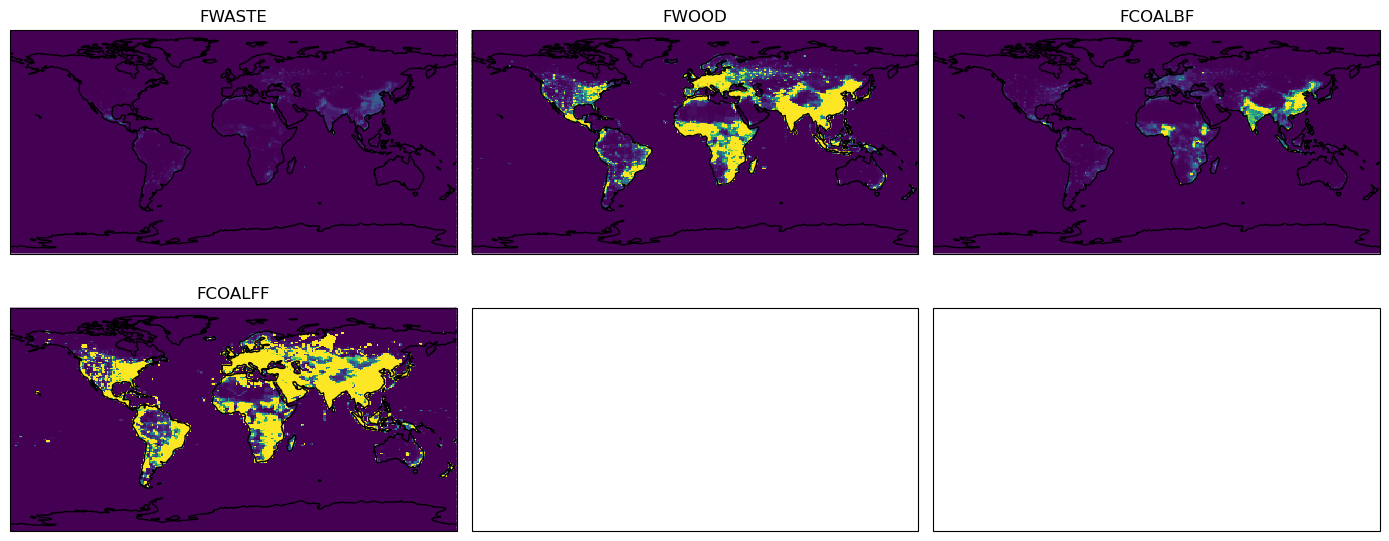

BC for REFERENCE


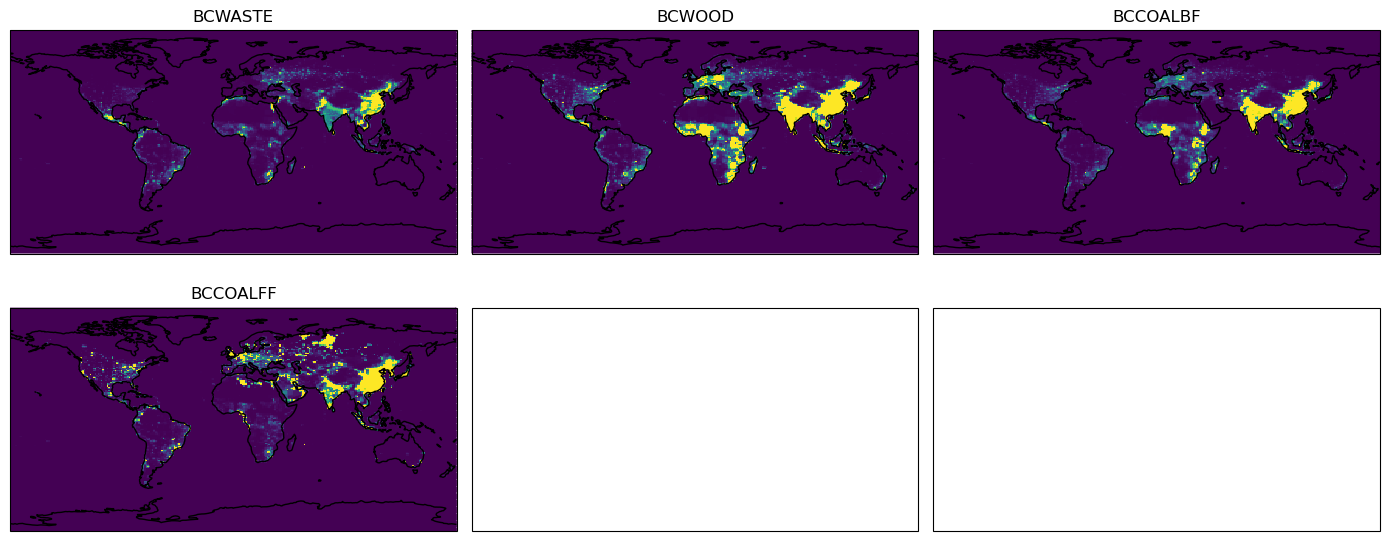

Fe_redistributed_flux


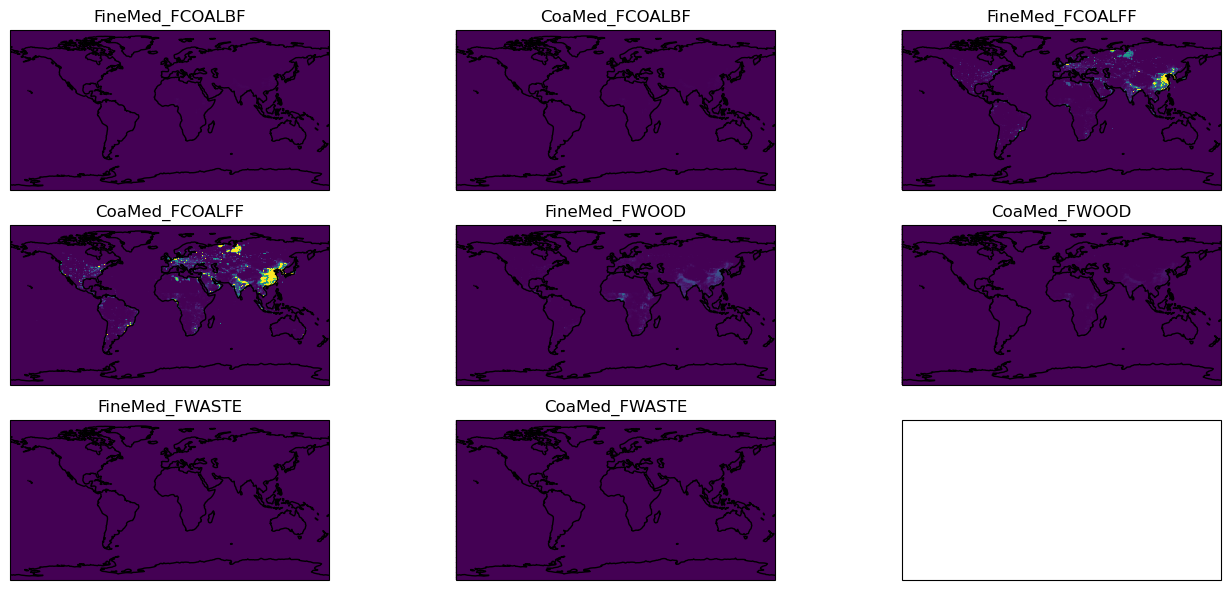

In [10]:
# BEFORE REDISTRIBUTION
vars_to_plot = ['FWASTE', 'FWOOD','FCOALBF', 'FCOALFF']

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    data = Fe_emiss[var]

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        add_colorbar=False,
        vmin = 1E-17,
        vmax= 1E-14
    )

    ax.coastlines()
    ax.set_title(var)
plt.tight_layout()
print("BEFORE REDISTRIBUTION")
plt.show()


# AFTER REDISTRIBUTION
vars_to_plot = ['FWASTE', 'FWOOD', 'FCOALBF', 'FCOALFF']

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    data = Fe_redistributed_flux[var]

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        add_colorbar=False,
        vmin = 1E-17,
        vmax= 1E-14
    )

    ax.coastlines()
    ax.set_title(var)

# shared colorbar
#cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.05)
#cbar.set_label('Emissions')

plt.tight_layout()
print("AFTER REDISTRIBUTION")
plt.show()

# BC FOR REFERENCE
BC_emiss = xr.Dataset({
    'BCCOALFF': BC_emiss_Ind,
    'BCOIL': BC_emiss_Oil,
    'BCCOALBF':  BC_emiss_Resi,
    'BCWOOD':  BC_emiss_Biof,
    'BCWASTE': BC_emiss_Was
})

BC_emiss = BC_emiss.clip(min=0.0)
BC_emiss = BC_emiss.fillna(0) 

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

vars_to_plot = ['BCWASTE', 'BCWOOD', 'BCCOALBF', 'BCCOALFF']

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    data = BC_emiss[var]

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        add_colorbar=False,
       vmin = 1E-16,
        vmax= 1E-12
    )

    ax.coastlines()
    ax.set_title(var)

plt.tight_layout()
print("BC for REFERENCE")
plt.show()

Fe_redistributed_flux


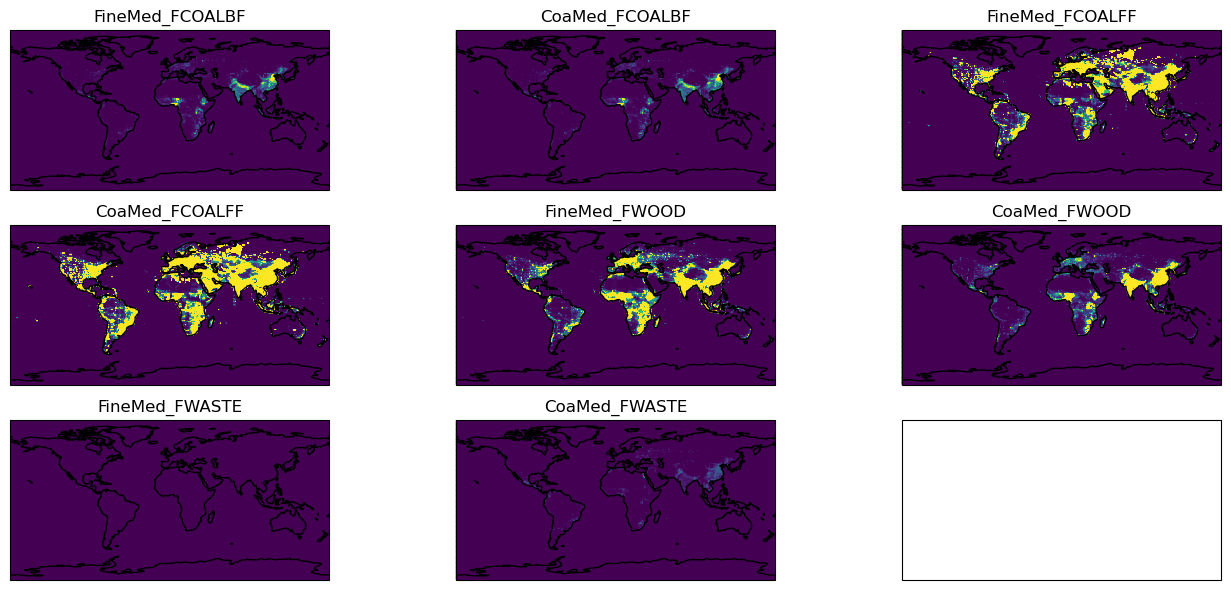

In [11]:
# AFTER SPLITTING FINE AND COARSE

Fe_redistributed_flux["FineMed_FCOALBF"] = Fe_redistributed_flux["FCOALBF"] *  0.5083 
Fe_redistributed_flux["CoaMed_FCOALBF"] = Fe_redistributed_flux["FCOALBF"] * 0.4917
Fe_redistributed_flux["FineMed_FCOALFF"] = Fe_redistributed_flux["FCOALFF"] *  0.2726  
Fe_redistributed_flux["CoaMed_FCOALFF"] = Fe_redistributed_flux["FCOALFF"] * 0.7274
Fe_redistributed_flux["FineMed_FWOOD"] = Fe_redistributed_flux["FWOOD"] * 0.8100   
Fe_redistributed_flux["CoaMed_FWOOD"] = Fe_redistributed_flux["FWOOD"] * 0.1900
Fe_redistributed_flux["FineMed_FWASTE"] = Fe_redistributed_flux["FWASTE"] *  0.0134   
Fe_redistributed_flux["CoaMed_FWASTE"] = Fe_redistributed_flux["FWASTE"] * 0.9866

vars_to_plot = ['FineMed_FCOALBF', 'CoaMed_FCOALBF', 'FineMed_FCOALFF', 'CoaMed_FCOALFF', 'FineMed_FWOOD', "CoaMed_FWOOD", "FineMed_FWASTE", "CoaMed_FWASTE"]

fig, axes = plt.subplots(
    3, 3,
    figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

axes = axes.flatten()

for ax, var in zip(axes, vars_to_plot):
    data = Fe_redistributed_flux[var]

    im = data.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        add_colorbar=False,
       vmin = 1E-16,
        vmax= 1E-14
    )

    ax.coastlines()
    ax.set_title(var)

plt.tight_layout()
print("Fe_redistributed_flux")
plt.show()

In [17]:
ds = xr.open_dataset("ClaquinMineralsCAM6_SPEWFUELS-Dec2023_OCNFRAC_remapcon_regridded.nc")
ds = Fe_emiss

for v in ds.data_vars:
    da = ds[v]
    
    print(f"\n=== {v} ===")
    print("dtype:", da.dtype)
    print("shape:", da.shape)
    
    # raw values check
    print("min:", float(da.min().values))
    print("max:", float(da.max().values))
    
    # NaN / masked checks
    print("has NaN:", bool(da.isnull().any()))
    
    # check for fill values / encoding
    print("encoding:", da.encoding)
    print("attrs:", da.attrs)
    
    # sample unique values (small subset to avoid memory blowup)
    print("unique sample:", np.unique(da.values[:10, :10]))


=== FWASTE ===
dtype: float64
shape: (192, 288)
min: 0.0
max: 5.340292821669201e-14
has NaN: False
encoding: {}
attrs: {}
unique sample: [0.]

=== FWOOD ===
dtype: float64
shape: (192, 288)
min: 0.0
max: 4.5468543128941025e-12
has NaN: False
encoding: {}
attrs: {}
unique sample: [0.]

=== FOIL ===
dtype: float64
shape: (192, 288)
min: 0.0
max: 7.451410365469369e-13
has NaN: False
encoding: {}
attrs: {}
unique sample: [0.]

=== FCOALBF ===
dtype: float64
shape: (192, 288)
min: 0.0
max: 1.393440937288992e-13
has NaN: False
encoding: {}
attrs: {}
unique sample: [0.]

=== FCOALFF ===
dtype: float64
shape: (192, 288)
min: 0.0
max: 2.101621411430138e-11
has NaN: False
encoding: {}
attrs: {}
unique sample: [0.]

=== FSMELT ===
dtype: float64
shape: (192, 288)
min: 0.0
max: 6.123112433753519e-11
has NaN: False
encoding: {}
attrs: {}
unique sample: [0.]

=== FineMed_FCOALFF ===
dtype: float64
shape: (192, 288)
min: 0.0
max: 6.7439265626773046e-12
has NaN: False
encoding: {}
attrs: {}
unique sa